### This code provides supports for results on Projection Analyses, including those in Main Text section 2.6 and SI section A.10.

In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap,ListedColormap
import matplotlib.cm as cm
import pandas as pd
import numpy as np
import seaborn as sns


d:\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
###data source: census
df_census = pd.read_csv('data/census/all_census_data_with_location.csv')

In [3]:
len(df_census[df_census['percent_above_65']>0.5]['county'].unique())

455

In [4]:
#17% 21% 24%
nowrate= 0.17 

growthrate30=0.21/nowrate

growthrate60=0.24/nowrate

df_census_proj=df_census[['census_block_group','percent_above_65']]
df_census_proj['2019_is_old']=df_census_proj.apply(lambda x: 1 if x['percent_above_65']>0.5 else 0.5,axis=1)
df_census_proj['2019_is_old']=df_census_proj.apply(lambda x: 0 if x['percent_above_65']<0.2 else x['2019_is_old'],axis=1)

df_census_proj['2030_percent_above_65']=df_census_proj['percent_above_65']*growthrate30
df_census_proj['2030_is_old']=df_census_proj.apply(lambda x: 1 if x['2030_percent_above_65']>0.5 else 0.5,axis=1)
df_census_proj['2030_is_old']=df_census_proj.apply(lambda x: 0 if x['2030_percent_above_65']<0.2 else x['2030_is_old'],axis=1)

df_census_proj['2060_percent_above_65']=df_census_proj['percent_above_65']*growthrate60
df_census_proj['2060_is_old']=df_census_proj.apply(lambda x: 1 if x['2060_percent_above_65']>0.5 else 0.5,axis=1)
df_census_proj['2060_is_old']=df_census_proj.apply(lambda x: 0 if x['2060_percent_above_65']<0.2 else x['2060_is_old'],axis=1)

C:\Users\Linao\AppData\Local\Temp\ipykernel_2672\2151901607.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_census_proj['2019_is_old']=df_census_proj.apply(lambda x: 1 if x['percent_above_65']>0.5 else 0.5,axis=1)
C:\Users\Linao\AppData\Local\Temp\ipykernel_2672\2151901607.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_census_proj['2019_is_old']=df_census_proj.apply(lambda x: 0 if x['percent_above_65']<0.2 else x['2019_is_old'],axis=1)
C:\Users\Linao\AppData\Local\Temp\ipykernel_2672\2151901

In [5]:
df_census_proj

,census_block_group,percent_above_65,2019_is_old,2030_percent_above_65,2030_is_old,2060_percent_above_65,2060_is_old
0,10010201001,0.036242,0.0,0.044769,0.0,0.051165,0.0
1,10010201002,0.114625,0.0,0.141595,0.0,0.161823,0.0
2,10010202001,0.161458,0.0,0.199449,0.0,0.227941,0.5
3,10010202002,0.094660,0.0,0.116933,0.0,0.133638,0.0
4,10010203001,0.134095,0.0,0.165646,0.0,0.189310,0.0
...,...,...,...,...,...,...,...
220328,721537506011,0.226927,0.5,0.280322,0.5,0.320368,0.5
220329,721537506012,0.107658,0.0,0.132989,0.0,0.151988,0.0
220330,721537506013,0.057741,0.0,0.071327,0.0,0.081516,0.0
220331,721537506021,0.220449,0.5,0.272319,0.5,0.311222,0.5


In [6]:
dict_state={'1': 'AL', '2': 'AK', '4': 'AZ', '5': 'AR', '6': 'CA', '8': 'CO', '9': 'CT', '10': 'DE', '11': 'DC', '12': 'FL', '13': 'GA', '15': 'HI', '16': 'ID',
            '17': 'IL', '18': 'IN', '19': 'IA', '20': 'KS', '21': 'KY', '22': 'LA', '23': 'ME', '24': 'MD', '25': 'MA', '26': 'MI', '27': 'MN', '28': 'MS', '29': 'MO',
            '30': 'MT', '31': 'NE', '32': 'NV', '33': 'NH', '34': 'NJ', '35': 'NM', '36': 'NY', '37': 'NC', '38': 'ND', '39': 'OH', '40': 'OK', '41': 'OR', '42': 'PA', 
            '44': 'RI', '45': 'SC', '46': 'SD', '47': 'TN', '48': 'TX', '49': 'UT', '50': 'VT', '51': 'VA', '53': 'WA', '54': 'WV', '55': 'WI', '56': 'WY', '60': 'AS', 
            '66': 'GU', '69': 'MP', '72': 'PR', '74': 'UM', '78': 'VI'}    

df_census_proj['census_block_group']=df_census_proj['census_block_group'].astype(str)

df_census_proj['state']=df_census_proj.apply(lambda x: dict_state[x['census_block_group'][:2]] if len(x['census_block_group'])==12 
                                                else dict_state[x['census_block_group'][:1]],
                                                axis=1)
df_census_proj['countyfip']=df_census_proj.apply(lambda x: x['census_block_group'][:5] if len(x['census_block_group'])==12 
                                                else '0'+x['census_block_group'][:4],
                                                axis=1)
agedict={0:'less than 0.2',1:'greater than 0.5',0.5:'mid'}
for pre in ['2019','2030','2060']:
    df_census_proj[pre+'_age']=df_census_proj.apply(lambda x: agedict[x[pre+'_is_old']], axis=1)

C:\Users\Linao\AppData\Local\Temp\ipykernel_2672\1921499059.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_census_proj['census_block_group']=df_census_proj['census_block_group'].astype(str)
C:\Users\Linao\AppData\Local\Temp\ipykernel_2672\1921499059.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_census_proj['state']=df_census_proj.apply(lambda x: dict_state[x['census_block_group'][:2]] if len(x['census_block_group'])==12
C:\Users\Linao\AppData\Local\Temp\ipykernel_2672\1921499059.py:12: Sett

In [7]:
df_census_proj

,census_block_group,percent_above_65,2019_is_old,2030_percent_above_65,2030_is_old,2060_percent_above_65,2060_is_old,state,countyfip,2019_age,2030_age,2060_age
0,10010201001,0.036242,0.0,0.044769,0.0,0.051165,0.0,AL,01001,less than 0.2,less than 0.2,less than 0.2
1,10010201002,0.114625,0.0,0.141595,0.0,0.161823,0.0,AL,01001,less than 0.2,less than 0.2,less than 0.2
2,10010202001,0.161458,0.0,0.199449,0.0,0.227941,0.5,AL,01001,less than 0.2,less than 0.2,mid
3,10010202002,0.094660,0.0,0.116933,0.0,0.133638,0.0,AL,01001,less than 0.2,less than 0.2,less than 0.2
4,10010203001,0.134095,0.0,0.165646,0.0,0.189310,0.0,AL,01001,less than 0.2,less than 0.2,less than 0.2
...,...,...,...,...,...,...,...,...,...,...,...,...
220328,721537506011,0.226927,0.5,0.280322,0.5,0.320368,0.5,PR,72153,mid,mid,mid
220329,721537506012,0.107658,0.0,0.132989,0.0,0.151988,0.0,PR,72153,less than 0.2,less than 0.2,less than 0.2
220330,721537506013,0.057741,0.0,0.071327,0.0,0.081516,0.0,PR,72153,less than 0.2,less than 0.2,less than 0.2
220331,721537506021,0.220449,0.5,0.272319,0.5,0.311222,0.5,PR,72153,mid,mid,mid


In [8]:
##state-level
#new measure of fairindex based on distribution difference
dict_state={'1': 'AL', '2': 'AK', '4': 'AZ', '5': 'AR', '6': 'CA', '8': 'CO', '9': 'CT', '10': 'DE', '11': 'DC', '12': 'FL', '13': 'GA', '15': 'HI', '16': 'ID',
            '17': 'IL', '18': 'IN', '19': 'IA', '20': 'KS', '21': 'KY', '22': 'LA', '23': 'ME', '24': 'MD', '25': 'MA', '26': 'MI', '27': 'MN', '28': 'MS', '29': 'MO',
            '30': 'MT', '31': 'NE', '32': 'NV', '33': 'NH', '34': 'NJ', '35': 'NM', '36': 'NY', '37': 'NC', '38': 'ND', '39': 'OH', '40': 'OK', '41': 'OR', '42': 'PA', 
            '44': 'RI', '45': 'SC', '46': 'SD', '47': 'TN', '48': 'TX', '49': 'UT', '50': 'VT', '51': 'VA', '53': 'WA', '54': 'WV', '55': 'WI', '56': 'WY', '60': 'AS', 
            '66': 'GU', '69': 'MP', '72': 'PR', '74': 'UM', '78': 'VI'}

col=['census_block_group','ParentType','num_accessible_facility','demand_ratios','demand_met_in_local']

listParentType=['Health Care Services',
                 'Pharmaceutical and Medical Supply Stores',
                 'Grocery and Food Supply',
                 'Social Assistance',
                 'Transportation Services',
                 'Home Health Care Services',
                 'Financial Services',
                 'Legal Services',
                 'Housing and Real Estate',
                 'Personal Care Services',
                 'Utility Services',
                 'Retail Stores for Basic Needs']

abb_dict={'Health Care Services':'HCS','Grocery and Food Supply':'GFS', 'Housing and Real Estate':'HRE'}
listParentType1=abb_dict.keys()


homoDistDiffFairList=[]

###data source: accratios 5 mile
for pre in ['2019','2030','2060']:
    for key in listParentType1: 
        homoPath='data/A under 5-mile setting/'+key+'.csv'
        dfHomo=pd.read_csv(homoPath,usecols=col)
###data source: accratios 5 mile

        dfHomo['census_block_group']=dfHomo['census_block_group'].astype(str)
        dfHomo['statefip']=dfHomo.apply(lambda x: x['census_block_group'][0:2] if len(x['census_block_group'])==12 
                                         else x['census_block_group'][0:1],axis=1)
        
        dfHomo=pd.merge(dfHomo, df_census_proj[['census_block_group',pre+'_age']])


        print('read data_'+key+'_'+pre)

        for fip in dict_state.keys():
            state=dict_state[fip]
            #print(state)
        #homo
            df_st=dfHomo[(dfHomo['statefip']==fip)&(dfHomo[pre+'_age']!='mid')]     

            #distribution-diff fairindex
            if len(df_st)>0:
                numold=len(df_st[(df_st[pre+'_age']=='greater than 0.5')&(df_st['demand_met_in_local']<=1)].dropna(subset=['demand_met_in_local']))
                numyoung=len(df_st[(df_st[pre+'_age']!='greater than 0.5')&(df_st['demand_met_in_local']<=1)].dropna(subset=['demand_met_in_local']))
                numcbg=len( df_st.dropna(subset=['demand_met_in_local']) )
                if (numold>0)&(numyoung>0):     
                    sumfair=0
                    for i in range(9):
                        thres=np.percentile(df_st[(df_st[pre+'_age']!='greater than 0.5')&
                                                (df_st['demand_met_in_local']<=1)].dropna(subset=['demand_met_in_local'])['demand_met_in_local'],i*10+10)
                        numGood=len(df_st[(df_st['demand_met_in_local']>=thres)&(df_st[pre+'_age']=='greater than 0.5')&
                                            (df_st['demand_met_in_local']<=1)].dropna(subset=['demand_met_in_local']))     
                        fairindex=numGood/numold-(1-(i*10+10)/100)
                        sumfair += fairindex

                    FairIndex=sumfair/4.5
                    homoDistDiffFairList.append((pre,key,state,FairIndex,'5 miles',numold,numcbg, numold/numcbg ))


        print('done'+key+'_'+pre)    
    
    


    
ProjDDFairDF=pd.DataFrame(homoDistDiffFairList,columns=['year','parentType','state','FairIndex','coverage',
                                                        'num_old_cbg','num_cbg','Ratio of old CBGs'])


read data_Health Care Services_2019
doneHealth Care Services_2019
read data_Grocery and Food Supply_2019
doneGrocery and Food Supply_2019
read data_Housing and Real Estate_2019
doneHousing and Real Estate_2019
read data_Health Care Services_2030
doneHealth Care Services_2030
read data_Grocery and Food Supply_2030
doneGrocery and Food Supply_2030
read data_Housing and Real Estate_2030
doneHousing and Real Estate_2030
read data_Health Care Services_2060
doneHealth Care Services_2060
read data_Grocery and Food Supply_2060
doneGrocery and Food Supply_2060
read data_Housing and Real Estate_2060
doneHousing and Real Estate_2060


In [9]:
##US-level
#new measure of fairindex based on distribution difference

col=['census_block_group','ParentType','num_accessible_facility','demand_ratios','demand_met_in_local']


abb_dict={'Health Care Services':'HCS','Grocery and Food Supply':'GFS', 'Housing and Real Estate':'HRE'}
listParentType1=abb_dict.keys()


homoDistDiffFairList=[]

###data source: accratios 5 mile
for pre in ['2019','2030','2060']:
    for key in listParentType1: 
        homoPath='data/A under 5-mile setting/'+key+'.csv'
        dfHomo=pd.read_csv(homoPath,usecols=col)
###data source: accratios 5 mile

        dfHomo['census_block_group']=dfHomo['census_block_group'].astype(str)
        dfHomo['statefip']=dfHomo.apply(lambda x: x['census_block_group'][0:2] if len(x['census_block_group'])==12 
                                         else x['census_block_group'][0:1],axis=1)
       

        dfHomo=pd.merge(dfHomo, df_census_proj[['census_block_group',pre+'_age']])


        print('read data_'+key+'_'+pre)


        #homo
        df_st=dfHomo[dfHomo[pre+'_age']!='mid'] 

        #distribution-diff fairindex
        if len(df_st)>0:
            numold=len(df_st[(df_st[pre+'_age']=='greater than 0.5')&(df_st['demand_met_in_local']<=1)].dropna(subset=['demand_met_in_local']))
            numcbg=len( df_st.dropna(subset=['demand_met_in_local']) )
            if numold>0:     
                sumfair=0
                for i in range(9):
                    thres=np.percentile(df_st[(df_st[pre+'_age']!='greater than 0.5')&
                                            (df_st['demand_met_in_local']<=1)].dropna(subset=['demand_met_in_local'])['demand_met_in_local'],i*10+10)
                    numGood=len(df_st[(df_st['demand_met_in_local']>=thres)&(df_st[pre+'_age']=='greater than 0.5')&
                                        (df_st['demand_met_in_local']<=1)].dropna(subset=['demand_met_in_local']) )     
                    fairindex=numGood/numold-(1-(i*10+10)/100)
                    sumfair += fairindex

                FairIndex=sumfair/4.5
                homoDistDiffFairList.append((pre,key,'US',FairIndex,'5 miles',numold,numcbg, numold/numcbg))


        print('done'+key+'_'+pre)    
    
    


    
ProjDDFairDF_US=pd.DataFrame(homoDistDiffFairList,columns=['year','parentType','state','FairIndex','coverage',
                                                           'num_old_cbg','num_cbg','Ratio of old CBGs'])


read data_Health Care Services_2019
doneHealth Care Services_2019
read data_Grocery and Food Supply_2019
doneGrocery and Food Supply_2019
read data_Housing and Real Estate_2019
doneHousing and Real Estate_2019
read data_Health Care Services_2030
doneHealth Care Services_2030
read data_Grocery and Food Supply_2030
doneGrocery and Food Supply_2030
read data_Housing and Real Estate_2030
doneHousing and Real Estate_2030
read data_Health Care Services_2060
doneHealth Care Services_2060
read data_Grocery and Food Supply_2060
doneGrocery and Food Supply_2060
read data_Housing and Real Estate_2060
doneHousing and Real Estate_2060


In [10]:
##county-level
#new measure of fairindex based on distribution difference

col=['census_block_group','ParentType','num_accessible_facility','demand_ratios','demand_met_in_local']


abb_dict={'Health Care Services':'HCS','Grocery and Food Supply':'GFS', 'Housing and Real Estate':'HRE'}
listParentType1=abb_dict.keys()


homoDistDiffFairList=[]
###data source: accratios 5 mile
for pre in ['2019','2030','2060']:
    for key in listParentType1: 
        homoPath='data/A under 5-mile setting/'+key+'.csv'
        dfHomo=pd.read_csv(homoPath,usecols=col)
###data source: accratios 5 mile
        dfHomo['census_block_group']=dfHomo['census_block_group'].astype(str)
        dfHomo['countyfip']=dfHomo.apply(lambda x: x['census_block_group'][0:5] if len(x['census_block_group'])==12 
                                         else '0'+x['census_block_group'][0:4],axis=1)


        dfHomo=pd.merge(dfHomo, df_census_proj[['census_block_group',pre+'_age']])


        print('read data_'+key+'_'+pre)

        for fip in dfHomo['countyfip'].unique():
            df_st=dfHomo[(dfHomo['countyfip']==fip)&(dfHomo[pre+'_age']!='mid')]     
            
            #distribution-diff fairindex
            if len(df_st)>0:
                numold=len(df_st[(df_st[pre+'_age']=='greater than 0.5')&(df_st['demand_met_in_local']<=1)].dropna(subset=['demand_met_in_local']) )
                numcbg=len(dfHomo[(dfHomo['countyfip']==fip)] )
                if numold>0:     
                    sumfair=0
                    if len(df_st[(df_st[pre+'_age']!='greater than 0.5')&(df_st['demand_met_in_local']<=1)].dropna(subset=['demand_met_in_local']) )>0:
                        for i in range(9):
                            thres=np.percentile(df_st[(df_st[pre+'_age']!='greater than 0.5')&
                                                    (df_st['demand_met_in_local']<=1)].dropna(subset=['demand_met_in_local'])['demand_met_in_local'],i*10+10)
                            numGood=len(df_st[(df_st['demand_met_in_local']>=thres)&(df_st[pre+'_age']=='greater than 0.5')&
                                                (df_st['demand_met_in_local']<=1)].dropna(subset=['demand_met_in_local']) )     
                            fairindex=numGood/numold-(1-(i*10+10)/100)
                            sumfair += fairindex
                        FairIndex=sumfair/4.5
                        homoDistDiffFairList.append((pre,key,fip,FairIndex,'5 miles',numold,numcbg, numold/numcbg ))

        print('done'+key+'_'+pre)    
    
    
ProjDDFairDF_county=pd.DataFrame(homoDistDiffFairList,columns=['year','parentType','countyfip','FairIndex','coverage',
                                                               'num_old_cbg','num_cbg','Ratio of old CBGs'])


read data_Health Care Services_2019


KeyboardInterrupt: 

In [12]:
df_census_proj

,census_block_group,percent_above_65,2019_is_old,2030_percent_above_65,2030_is_old,2060_percent_above_65,2060_is_old,state,countyfip,2019_age,2030_age,2060_age
0,10010201001,0.036242,0.0,0.044769,0.0,0.051165,0.0,AL,01001,less than 0.2,less than 0.2,less than 0.2
1,10010201002,0.114625,0.0,0.141595,0.0,0.161823,0.0,AL,01001,less than 0.2,less than 0.2,less than 0.2
2,10010202001,0.161458,0.0,0.199449,0.0,0.227941,0.5,AL,01001,less than 0.2,less than 0.2,mid
3,10010202002,0.094660,0.0,0.116933,0.0,0.133638,0.0,AL,01001,less than 0.2,less than 0.2,less than 0.2
4,10010203001,0.134095,0.0,0.165646,0.0,0.189310,0.0,AL,01001,less than 0.2,less than 0.2,less than 0.2
...,...,...,...,...,...,...,...,...,...,...,...,...
220328,721537506011,0.226927,0.5,0.280322,0.5,0.320368,0.5,PR,72153,mid,mid,mid
220329,721537506012,0.107658,0.0,0.132989,0.0,0.151988,0.0,PR,72153,less than 0.2,less than 0.2,less than 0.2
220330,721537506013,0.057741,0.0,0.071327,0.0,0.081516,0.0,PR,72153,less than 0.2,less than 0.2,less than 0.2
220331,721537506021,0.220449,0.5,0.272319,0.5,0.311222,0.5,PR,72153,mid,mid,mid


In [12]:
#ppath='D:\main\1_research\P10_Mobility\p10_aging mobility\results_all_states\allStatesByParentType\projection'
#df_census_proj.to_csv(r'D:\main\1_research\P10_Mobility\p10_aging mobility\results_all_states\allStatesByParentType\projection\df_census_proj_50_20.csv')

In [20]:
ProjDDFairDF[(ProjDDFairDF['state'].isin(['CA','FL','AZ']))]

,year,parentType,state,FairIndex,coverage,num_old_cbg,num_cbg,Ratio of old CBGs
1,2019,Health Care Services,AZ,0.041363,5 miles,274,3228,0.084882
3,2019,Health Care Services,CA,-0.075969,5 miles,215,18675,0.011513
7,2019,Health Care Services,FL,0.146886,5 miles,851,7771,0.109510
48,2019,Grocery and Food Supply,AZ,-0.084150,5 miles,272,3227,0.084289
50,2019,Grocery and Food Supply,CA,-0.167186,5 miles,214,18684,0.011454
54,2019,Grocery and Food Supply,FL,0.121780,5 miles,854,7772,0.109882
95,2019,Housing and Real Estate,AZ,0.017843,5 miles,274,3243,0.084490
97,2019,Housing and Real Estate,CA,-0.002537,5 miles,219,18723,0.011697
101,2019,Housing and Real Estate,FL,0.142783,5 miles,856,7784,0.109969
142,2030,Health Care Services,AZ,-0.000281,5 miles,395,3009,0.131273


In [14]:
f2019=ProjDDFairDF[(ProjDDFairDF['state']=='AZ')&(ProjDDFairDF['year']=='2019')]['FairIndex'].iat[0]
f2060=ProjDDFairDF[(ProjDDFairDF['state']=='AZ')&(ProjDDFairDF['year']=='2060')]['FairIndex'].iat[0]
f2030=ProjDDFairDF[(ProjDDFairDF['state']=='AZ')&(ProjDDFairDF['year']=='2030')]['FairIndex'].iat[0]
drate1=(f2019-f2030)/f2019
drate2=(f2030-f2060)/f2030
print(f2019,f2030,f2060,drate1,drate2)

0.0413625304136253 -0.00028129395218004196 0.0027434842249657123 1.0068006949615294 10.753086419752629


In [15]:
#ProjDDFairDF.to_csv(r'D:\main\1_research\P10_Mobility\p10_aging mobility\results_all_states\allStatesByParentType\projection\ProjDDFairDF_state_50_20.csv')

In [15]:
ProjDDFairDF_US

,year,parentType,state,FairIndex,coverage,num_old_cbg,num_cbg,Ratio of old CBGs
0,2019,Health Care Services,US,0.112587,5 miles,2258,165244,0.013665
1,2019,Grocery and Food Supply,US,0.044140,5 miles,2263,165431,0.013679
2,2019,Housing and Real Estate,US,0.168009,5 miles,2277,165636,0.013747
3,2030,Health Care Services,US,0.035153,5 miles,4757,134803,0.035289
4,2030,Grocery and Food Supply,US,-0.038063,5 miles,4764,134941,0.035304
5,2030,Housing and Real Estate,US,0.054383,5 miles,4787,135110,0.035430
6,2060,Health Care Services,US,-0.005329,5 miles,7819,116141,0.067323
7,2060,Grocery and Food Supply,US,-0.078571,5 miles,7833,116245,0.067384
8,2060,Housing and Real Estate,US,0.002386,5 miles,7869,116410,0.067597


In [18]:
df_a=pd.concat([ProjDDFairDF[(ProjDDFairDF['state'].isin(['CA','FL','AZ']))], ProjDDFairDF_US ])

In [21]:
df_a=df_a[['year','parentType','state','FairIndex']].rename(columns={'parentType':'service_type','FairIndex':'fairness_index','state':'region'})

In [22]:
df_a

,year,service_type,region,fairness_index
1,2019,Health Care Services,AZ,0.041363
3,2019,Health Care Services,CA,-0.075969
7,2019,Health Care Services,FL,0.146886
48,2019,Grocery and Food Supply,AZ,-0.084150
50,2019,Grocery and Food Supply,CA,-0.167186
54,2019,Grocery and Food Supply,FL,0.121780
95,2019,Housing and Real Estate,AZ,0.017843
97,2019,Housing and Real Estate,CA,-0.002537
101,2019,Housing and Real Estate,FL,0.142783
142,2030,Health Care Services,AZ,-0.000281


In [17]:
#ProjDDFairDF_US.to_csv(r'D:\main\1_research\P10_Mobility\p10_aging mobility\results_all_states\allStatesByParentType\projection\ProjDDFairDF_US_50_20.csv')

In [ ]:
#ProjDDFairDF_county=pd.read_csv(r'D:\main\1_research\P10_Mobility\p10_aging mobility\R1\new results\projection\ProjDDFairDF_county_50_20.csv')
#ProjDDFairDF_county['year']=ProjDDFairDF_county['year'].astype(str)

In [23]:
df_b=ProjDDFairDF_county[['year','parentType','countyfip','FairIndex','Ratio of old CBGs']].rename(columns={'parentType':'service_type','FairIndex':'fairness_index','Ratio of old CBGs':'ratio_of_HighAging_CBGs'})

In [24]:
df_b

,year,service_type,countyfip,fairness_index,ratio_of_HighAging_CBGs
0,2019,Health Care Services,1003,-0.037037,0.031915
1,2019,Health Care Services,1015,-0.777778,0.010989
2,2019,Health Care Services,1073,0.777778,0.001931
3,2019,Health Care Services,1077,0.111111,0.013699
4,2019,Health Care Services,1089,0.777778,0.005236
...,...,...,...,...,...
8395,2060,Housing and Real Estate,72131,-0.777778,0.040000
8396,2060,Housing and Real Estate,72137,0.111111,0.016667
8397,2060,Housing and Real Estate,72139,0.629630,0.071429
8398,2060,Housing and Real Estate,72145,-0.333333,0.026316


In [20]:
#ProjDDFairDF_county.to_csv(r'D:\main\1_research\P10_Mobility\p10_aging mobility\R1\new results\projection\ProjDDFairDF_county_50_20.csv')

d:\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf

Health Care Services 2019 -0.295197305894785 0.16513229299553067
Health Care Services 2030 -0.8226124697455082 0.20854484383340446


C:\Users\Linao\AppData\Local\Temp\ipykernel_13440\4109884953.py:64: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = results.params[1]
C:\Users\Linao\AppData\Local\Temp\ipykernel_13440\4109884953.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept = results.params[0]
C:\Users\Linao\AppData\Local\Temp\ipykernel_13440\4109884953.py:64: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = results.params[1]
C:\Users\Lin

Health Care Services 2060 -0.7101460582924414 0.19748165833866596
Grocery and Food Supply 2019 1.2458328114407724 0.0067896341897418205


C:\Users\Linao\AppData\Local\Temp\ipykernel_13440\4109884953.py:64: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = results.params[1]
C:\Users\Linao\AppData\Local\Temp\ipykernel_13440\4109884953.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept = results.params[0]
C:\Users\Linao\AppData\Local\Temp\ipykernel_13440\4109884953.py:64: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = results.params[1]
C:\Users\Lin

Grocery and Food Supply 2030 0.14480430144245732 0.06094344703876619
Grocery and Food Supply 2060 -0.23874287888951173 0.08379584075367519


C:\Users\Linao\AppData\Local\Temp\ipykernel_13440\4109884953.py:64: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = results.params[1]
C:\Users\Linao\AppData\Local\Temp\ipykernel_13440\4109884953.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept = results.params[0]
C:\Users\Linao\AppData\Local\Temp\ipykernel_13440\4109884953.py:64: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = results.params[1]
C:\Users\Lin

Housing and Real Estate 2019 1.55860755416749 0.12841960313050832
Housing and Real Estate 2030 1.1194600086550044 0.20484434478218713
Housing and Real Estate 2060 0.9097979056297545 0.19638425885766392


C:\Users\Linao\AppData\Local\Temp\ipykernel_13440\4109884953.py:64: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = results.params[1]
C:\Users\Linao\AppData\Local\Temp\ipykernel_13440\4109884953.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept = results.params[0]


Text(-0.2, 1.1, 'b')

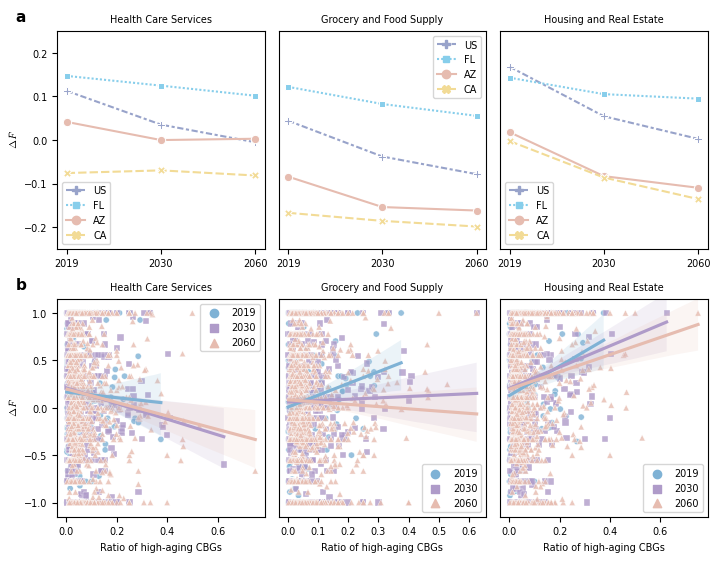

In [28]:
import statsmodels.api as sm

width_in_inches = 180 * 0.0393701
height_in_inches =width_in_inches/9*7
fig, ax=plt.subplots(2,3,constrained_layout=True, figsize=(width_in_inches, height_in_inches))#
abb_dict={'Health Care Services':'HCS','Grocery and Food Supply':'GFS', 'Housing and Real Estate':'HRE'}


color_dict={'Health Care Services':'#B3D8D5','Grocery and Food Supply':'#E7C1D7', 'Housing and Real Estate':'#F8D8B9'}
mainPType=color_dict.keys()
state_color_dict={'US':'#98A3CA','FL':'skyblue', 'AZ':'#E6BCB0','CA':'#F2DB96'}

year_dict={'2019':'#7FB2D5','2030':'#AF9BC9', '2060':'#E6BCB0'}

k=30
dfD=ProjDDFairDF[ProjDDFairDF['num_old_cbg']>=k]

        
#US FL AZ CA outcome

df_state_us=pd.concat([ProjDDFairDF,ProjDDFairDF_US])
df_state_us=df_state_us[df_state_us['state'].isin(['US','FL','AZ','CA'])]


for j, key in enumerate(mainPType): 
    
    s=sns.lineplot(x='year',y='FairIndex',data=df_state_us[df_state_us['parentType']==key],ax=ax[0][j],hue='state',style='state',
                   palette=state_color_dict,hue_order=['US','FL','AZ','CA'],markers=True)
    s.set_title(key,fontsize=7)
    
    ax[0, j].legend(title='',fontsize=7)
    
    ax[0, j].set_ylim([-0.25, 0.25])
    
    ax[0, j].set_xlabel('')
    
    if j>0:
        ax[0, j].set_ylabel('')
        ax[0, j].set_yticks([])
    else:
        ax[0, j].set_yticks([-0.2,-0.1,0,0.1,0.2])
        ax[0, j].set_ylabel(r'$\Delta \bar F$',usetex=True,fontsize=7)
    s.tick_params(axis='both', which='both', bottom=True, left=True,labelsize=7)     
for j, key in enumerate(mainPType): #key='Health Care Services'
    #
    dfD=ProjDDFairDF_county
    s=sns.scatterplot(x='Ratio of old CBGs',y='FairIndex',hue='year',data=dfD[dfD['parentType']==key],ax=ax[1][j],alpha=0.8,s=20,
                        palette=year_dict,style='year', markers={'2019': 'o', '2030': 's', '2060': '^'})
    s.set_title(key,fontsize=7)
    ax[1, j].legend(title='',fontsize=7)
    ax[1, j].set_ylim([-1.15, 1.15])

    for pre in ['2019','2030','2060']:
        sn=sns.regplot(data=dfD[(dfD['parentType']==key)&(dfD['year']==pre)], x="Ratio of old CBGs", y='FairIndex',
                       color=year_dict[pre],scatter=False, ax=ax[1][j])
        
        #regression
        data=dfD[(dfD['parentType']==key)&(dfD['year']==pre)]
        x = data['Ratio of old CBGs']
        y = data['FairIndex']
        x_with_constant = sm.add_constant(x)  # 添加常数项
        model = sm.OLS(y, x_with_constant)
        results = model.fit()
        slope = results.params[1]
        intercept = results.params[0]
        print(key,pre,slope,intercept)

    if j>0:
        ax[1, j].set_ylabel('')
        ax[1, j].set_yticks([])
    else:
        ax[1, j].set_yticks([-1.0,-0.5,0,0.5,1])
        ax[1, j].set_ylabel(r'$\Delta \bar F$',usetex=True,fontsize=7)
        
    ax[1, j].set_xlabel('Ratio of high-aging CBGs',fontsize=7)
    s.tick_params(axis='both', which='both', bottom=True, left=True,labelsize=7)    



ax[0,0].text(-0.2, 1.1, 'a', transform=ax[0,0].transAxes, fontsize=11, fontweight='bold', va='top', ha='left')

ax[1,0].text(-0.2, 1.1, 'b', transform=ax[1,0].transAxes, fontsize=11, fontweight='bold', va='top', ha='left')

In [ ]:
#fig.savefig(r'D:\main\1_research\P10_Mobility\p10_aging mobility\R1\new results\projection\fairindex_no_distribution_50_20.pdf', dpi=300, bbox_inches='tight', format='pdf')


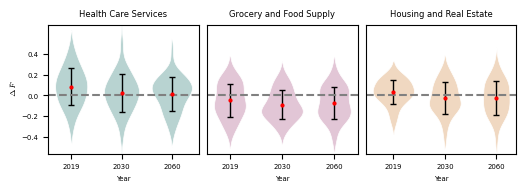

In [23]:
fig, ax=plt.subplots(1,3,constrained_layout=True, figsize=(372/72.27, 130/72.27))#
abb_dict={'Health Care Services':'HCS','Grocery and Food Supply':'GFS', 'Housing and Real Estate':'HRE'}


color_dict={'Health Care Services':'#B3D8D5','Grocery and Food Supply':'#E7C1D7', 'Housing and Real Estate':'#F8D8B9'}
mainPType=color_dict.keys()
state_color_dict={'US':'#98A3CA','FL':'skyblue', 'AZ':'#E6BCB0','CA':'#F2DB96'}

year_dict={'2019':'#7FB2D5','2030':'#AF9BC9', '2060':'#E6BCB0'}

k=30
dfD=ProjDDFairDF[ProjDDFairDF['num_old_cbg']>=k]
for j, key in enumerate(mainPType): 
    data=dfD[dfD['parentType']==key]
    sn = sns.violinplot(x='year', y='FairIndex', data=data,ax=ax[j], linewidth=0.5,inner=None,color=color_dict[key])  # inner=None 使得不显示小提琴图内部的默认内容

    for violin in sn.collections:
        violin.set_edgecolor('white')
        
    # 
    for i, category in enumerate(dfD['year'].unique()):
        subset = data[data['year'] == category]['FairIndex']
        mean = subset.mean()
        std = subset.std()

        #
        sn.scatter(i, mean, color='red', s=4, zorder=3, label=f'{category} mean' if i == 0 else "")

        #
        sn.errorbar(i, mean, yerr=std, color='black', capsize=2, fmt='none', lw=1, zorder=2)

    # 
    handles, labels = sn.get_legend_handles_labels()
    handles = handles[:1]  # 
    labels = labels[:1]    # 
   
    sn.set_title(key, fontsize=6)
    
    
    ax[ j].set_ylim([-0.56, 0.68])
    
    ax[j].set_xlabel('Year', fontsize=5)
    
    if j>0:
        ax[j].set_ylabel('')
        ax[ j].set_yticks([])
    else:
        ax[ j].set_yticks([-0.4,-0.2,0,0.2,0.4])
        ax[ j].set_ylabel(r'$\Delta \bar F$',usetex=True, fontsize=5)
        
    ax[j].axhline(0,color='gray',linestyle='dashed')
    ax[j].tick_params(axis='both', which='both', bottom=True, left=True, labelsize=5)

In [24]:
#fig.savefig('D:/main/1_research/P10_Mobility/p10_aging mobility/results_all_states/allStatesByParentType/SI/{}.jpg'.format('fairindex_distribution_dynamics_projection-372pt_50_20'),dpi=600
#           ,bbox_inches='tight') #b

migration

In [25]:
###data source: processed count-level migration data and census data
df_ct_fl=pd.read_csv('data/migration/FL_county_demographic_after_migration.csv')
#df_census=pd.read_csv('../../../new data/census/all_census_data_with_location.csv')
###data source

df_census['state']=df_census['state'].astype(str)

In [26]:
df_fl=df_census[df_census['state']=='12'][['census_block_group','county','population_by_age','above_65','percent_above_65']]
df_fl['M_percent_above_65']=df_fl.apply(lambda x: x['percent_above_65']+ df_ct_fl[df_ct_fl['countyfip']==x['county']]['M_diff'].iat[0],axis=1)

df_fl['52age']=df_fl.apply(lambda x: 0 if x['percent_above_65']<0.2 else 0.5, axis=1 )
df_fl['52age']=df_fl.apply(lambda x: 1 if x['percent_above_65']>0.5 else x['52age'], axis=1 )

df_fl['M_52age']=df_fl.apply(lambda x: 0 if x['M_percent_above_65']<0.2 else 0.5, axis=1 )
df_fl['M_52age']=df_fl.apply(lambda x: 1 if x['M_percent_above_65']>0.5 else x['M_52age'], axis=1 )

df_fl['DIFF']=df_fl['M_52age']-df_fl['52age']

In [27]:
print('number of CBGs labeling high-aging before migration:', len(df_fl[(df_fl['52age']==1)]) )
print('number of CBGs labeling high-aging after migration:', len(df_fl[(df_fl['M_52age']==1)]) )
print( 'number of CBGs labeling high-aging before and after migration:',len( df_fl[(df_fl['DIFF']==0)&(df_fl['52age']==1)] ) )
print( 'number of CBGs affected by migration:', len(df_fl[(df_fl['DIFF']!=0)] ))
print('number of CBGs in FL:',len(df_fl) )
print('number of CBGs labeling low-aging before migration:', len(df_fl[(df_fl['52age']==0)]) )
print('number of CBGs labeling low-aging after migration:', len(df_fl[(df_fl['M_52age']==0)]) )
print( 'number of CBGs labeling low-aging before and after migration:',len( df_fl[(df_fl['DIFF']==0)&(df_fl['52age']==0)] ) )

number of CBGs labeling high-aging before migration: 856
number of CBGs labeling high-aging after migration: 838
number of CBGs labeling high-aging before and after migration: 836
number of CBGs affected by migration: 120
number of CBGs in FL: 11442
number of CBGs labeling low-aging before migration: 6980
number of CBGs labeling low-aging after migration: 7048
number of CBGs labeling low-aging before and after migration: 6965


In [ ]:
#with pd.ExcelWriter('SourceData_Fig7.xlsx') as writer:
#    df_a.to_excel(writer, sheet_name='Fig7a', index=False)
#    df_b.to_excel(writer, sheet_name='Fig7b', index=False)